In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
df = pd.read_csv("FOODWASTETable2.csv")
df.head()

,date,city,AREA_TYPE,food_type,reason,quantity_kg
0,2025-01-01,Mumbai,Urban,Packed Food,Improper Storage,50.0
1,2025-01-02,pune,Semi-Urban,Cooked Food,Overproduction,51.0
2,2025-01-03,Hyderabad,Rural,Cooked Food,Event Leftover,52.0
3,2025-01-04,Dehli,Urban,Raw Vegetables,Low Demand,53.0
4,2025-01-05,Ahmedabad,Semi-Urban,Fruits,Improper Storage,50.0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         397 non-null    object 
 1   city         397 non-null    object 
 2   AREA_TYPE    397 non-null    object 
 3   food_type    397 non-null    object 
 4   reason       397 non-null    object 
 5   quantity_kg  397 non-null    float64
dtypes: float64(1), object(5)
memory usage: 18.7+ KB


In [3]:
df.isnull().sum()

date           0
city           0
AREA_TYPE      0
food_type      0
reason         0
quantity_kg    0
dtype: int64

In [4]:
df = df.drop_duplicates()
df = df.fillna(0)

In [5]:
total_waste = df["quantity_kg"].sum()
print("Total Food Waste : ", total_waste)
print(df.columns)

Total Food Waste :  20444.0
Index(['date', 'city', 'AREA_TYPE', 'food_type', 'reason', 'quantity_kg'], dtype='object')


In [6]:
food_type_analysis = df.groupby("food_type")["quantity_kg"].sum()
print(food_type_analysis)

food_type
 Packed Food       3416.0
Cooked Food       10230.0
Fruits             3366.0
Raw Vegetables     3432.0
Name: quantity_kg, dtype: float64


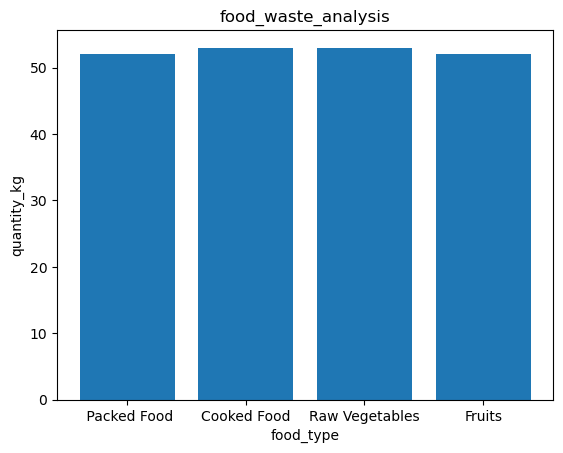

In [7]:
plt.bar(df["food_type"],df["quantity_kg"])
plt.title("food_waste_analysis")
plt.xlabel("food_type")
plt.ylabel("quantity_kg")

plt.show()

In [8]:
conn = sqlite3.connect("food_waste_db")

In [9]:
df.to_sql("food_waste_data", conn, 
          if_exists="replace", index=False)  
print("Data stored in database")

Data stored in database


In [10]:
query = "SELECT * FROM food_waste_data LIMIT 5"
result = pd.read_sql(query, conn)  

print(result)

         date       city   AREA_TYPE       food_type            reason  \
0  2025-01-01     Mumbai       Urban     Packed Food  Improper Storage   
1  2025-01-02       pune  Semi-Urban     Cooked Food    Overproduction   
2  2025-01-03  Hyderabad       Rural     Cooked Food    Event Leftover   
3  2025-01-04      Dehli       Urban  Raw Vegetables        Low Demand   
4  2025-01-05  Ahmedabad  Semi-Urban          Fruits  Improper Storage   

   quantity_kg  
0         50.0  
1         51.0  
2         52.0  
3         53.0  
4         50.0  


In [11]:
conn.close()

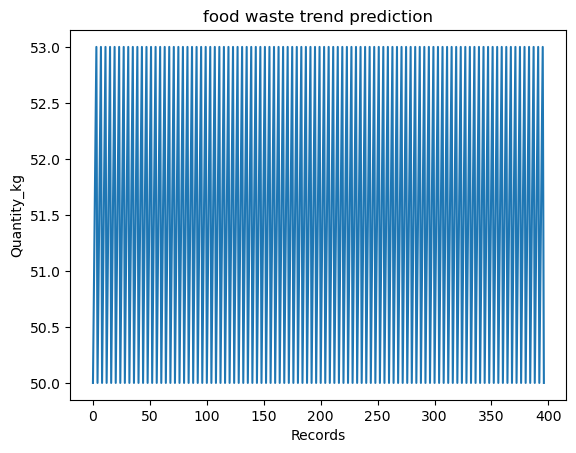

In [12]:
import matplotlib.pyplot as plt
plt.plot(df["quantity_kg"])
plt.title("food waste trend prediction")
plt.xlabel("Records")
plt.ylabel("Quantity_kg")

plt.show() 

In [13]:
location_waste = df.groupby("city")["quantity_kg"].sum()

print(location_waste)

city
Ahmedabad    2500.0
Bengaluru    2499.0
Chennai      2548.0
Dehli        2650.0
Hyderabad    2600.0
Kolkata      2597.0
Mumbai       2500.0
pune         2550.0
Name: quantity_kg, dtype: float64


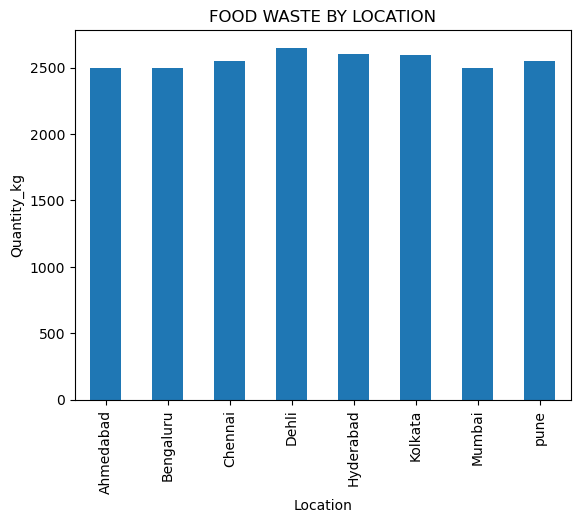

In [14]:
location_waste.plot(kind="bar")

plt.title("FOOD WASTE BY LOCATION")
plt.xlabel("Location")
plt.ylabel("Quantity_kg")

plt.show() 

In [15]:
food_waste = df.groupby("food_type")["quantity_kg"].sum()
print("Most Wasted Food Items : ")
print(food_waste.sort_values(ascending=False)) 

Most Wasted Food Items : 
food_type
Cooked Food       10230.0
Raw Vegetables     3432.0
 Packed Food       3416.0
Fruits             3366.0
Name: quantity_kg, dtype: float64


In [16]:
print("Project Insights:")

print("1. Some locations produce more food waste than others.")

print("2. Certain food types are wasted more frequently.")

print("3. Data analysis helps identify patterns in food waste.")

print("4. These insights can help reduce food waste through better planning. ")  


Project Insights:
1. Some locations produce more food waste than others.
2. Certain food types are wasted more frequently.
3. Data analysis helps identify patterns in food waste.
4. These insights can help reduce food waste through better planning. 


In [17]:
import folium

In [18]:
india_map = folium.Map(location=[20.5937, 78.9629], zoom_start=5)
india_map

In [19]:
df.columns

Index(['date', 'city', 'AREA_TYPE', 'food_type', 'reason', 'quantity_kg'], dtype='object')

In [23]:
print("Conclusion:")
print("This project analyzes food waste data using Python.")
print("Using data analysis and visualization, we identified key waste patterns.")
print("The results can help organizations manage food waste more effectively.")
print("Future improvements could include machine learning models for prediction.")
print("### Food Waste Location Map ###")
print("The following map visualizes the locations where food waste was recorded.")
print("This helps identify geographic areas where waste management strategies can be improved.") 

Conclusion:
This project analyzes food waste data using Python.
Using data analysis and visualization, we identified key waste patterns.
The results can help organizations manage food waste more effectively.
Future improvements could include machine learning models for prediction.
### Food Waste Location Map ###
The following map visualizes the locations where food waste was recorded.
This helps identify geographic areas where waste management strategies can be improved.


In [24]:
import folium

city_coords = {
    "Mumbai": [19.0760, 72.8777],
    "Delhi": [28.7041, 77.1025],
    "Bangalore": [12.9716, 77.5946],
    "Chennai": [13.0827, 80.2707],
    "Kolkata": [22.5726, 88.3639],
    "Hyderabad": [17.3850, 78.4867],
    "Pune": [18.5204, 73.8567]
}
india_map = folium.Map(location=[20.5937, 78.9629], zoom_start=5)

for city in df["city"]:
    if city in city_coords:
        folium.Marker(
            location=city_coords[city],
            popup=city
        ).add_to(india_map)

india_map